# Phase 1 — Binary Image Classification on MNIST
## Machine Learning Pipeline

 
 

## 1. Problem Definition

### 1.1 Mathematical Formulation

We define a **binary classification** problem over grayscale handwritten digit images.

**Input Space:**  
Each image $\mathbf{x} \in \mathbb{R}^{784}$ is a flattened $28 \times 28$ pixel grayscale image, where each pixel $x_i \in [0, 1]$ after normalization.

**Output Space:**  
$$y \in \{0, 1\}$$
where $y = 1$ represents digit **7** and $y = 0$ represents **any other digit**.

**Hypothesis Function:**  
$$h : \mathbb{R}^{d} \rightarrow \{0, 1\}$$

**KNN Decision Rule:**  
Given query point $\mathbf{x}_q$, find the $k$ nearest neighbors $\mathcal{N}_k(\mathbf{x}_q)$ from training set $\mathcal{D}_{train}$:
$$\hat{y} = \underset{c \in \{0,1\}}{\arg\max} \sum_{(\mathbf{x}_i, y_i) \in \mathcal{N}_k(\mathbf{x}_q)} \mathbb{1}[y_i = c]$$

**Distance Metric (Euclidean):**  
$$d(\mathbf{x}_q, \mathbf{x}_i) = \left\| \mathbf{x}_q - \mathbf{x}_i \right\|_2 = \sqrt{\sum_{j=1}^{d}(x_{q,j} - x_{i,j})^2}$$

---
## 2. Imports & Setup

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
from skimage.feature import hog
import warnings
warnings.filterwarnings('ignore')


---
## 3. Data Loading & Exploration

In [20]:
from tensorflow.keras.datasets import mnist

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

print(f'Train images : {X_train_raw.shape}')
print(f'Test images  : {X_test_raw.shape}')
print(f'Pixel range  : [{X_train_raw.min()}, {X_train_raw.max()}]')

Train images : (60000, 28, 28)
Test images  : (10000, 28, 28)
Pixel range  : [0, 255]


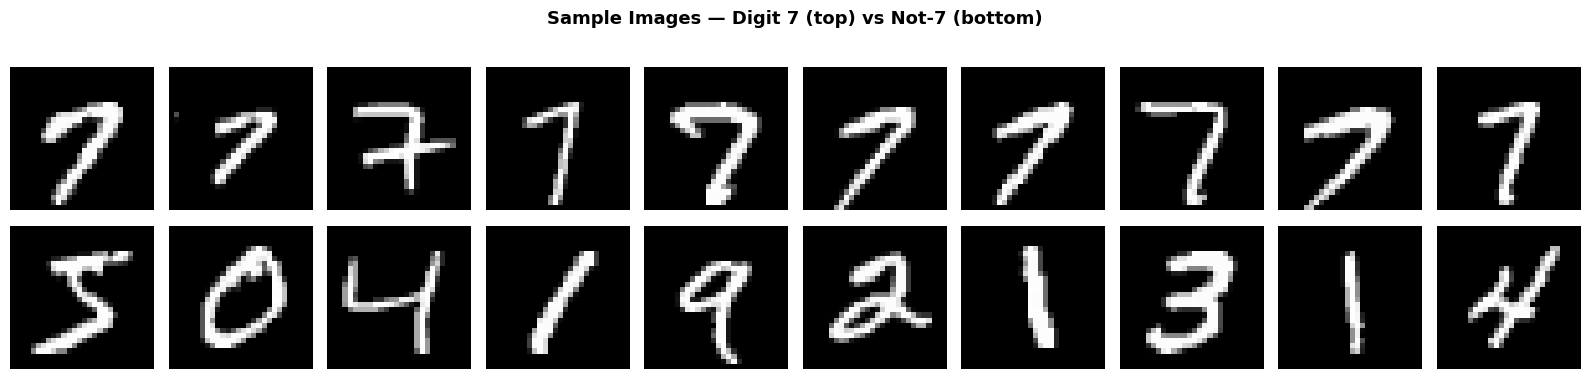

In [21]:
# Visualise sample digit-7 images
idx7 = np.where(y_train_raw == 7)[0][:10]
idx_not7 = np.where(y_train_raw != 7)[0][:10]

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('Sample Images — Digit 7 (top) vs Not-7 (bottom)', fontsize=13, fontweight='bold')
for col in range(10):
    axes[0, col].imshow(X_train_raw[idx7[col]], cmap='gray'); axes[0, col].axis('off')
    axes[1, col].imshow(X_train_raw[idx_not7[col]], cmap='gray'); axes[1, col].axis('off')
plt.tight_layout()
plt.show()

---
## 4. Data Processing

### 4.1 Binary Label Encoding

We convert the 10-class labels into a binary problem:
$$y = \begin{cases} 1 & \text{if digit} = 7 \\ 0 & \text{otherwise} \end{cases}$$

In [22]:
y_train_bin = (y_train_raw == 7).astype(int)
y_test_bin  = (y_test_raw  == 7).astype(int)

print('Training label distribution (before balancing):')
c = Counter(y_train_bin)
print(f'  Not-7 (0): {c[0]:>6}  ({c[0]/len(y_train_bin)*100:.1f}%)')
print(f'  Digit-7(1): {c[1]:>5}  ({c[1]/len(y_train_bin)*100:.1f}%)')

Training label distribution (before balancing):
  Not-7 (0):  53735  (89.6%)
  Digit-7(1):  6265  (10.4%)


### 4.2 Image Normalisation

Pixel values are scaled from $[0, 255]$ to $[0, 1]$ using Min-Max normalisation:
$$\tilde{x}_i = \frac{x_i}{255}$$

This ensures all features are on the same scale, preventing pixels with higher intensity from dominating the Euclidean distance computation.

In [23]:
X_train_norm = X_train_raw.reshape(-1, 784) / 255.0
X_test_norm  = X_test_raw.reshape(-1, 784)  / 255.0

print(f'Shape after flatten+normalise: {X_train_norm.shape}')
print(f'Pixel range: [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]')

Shape after flatten+normalise: (60000, 784)
Pixel range: [0.0, 1.0]


### 4.3 Train / Validation / Test Split

 

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_norm,
    y_train_bin,
    test_size=0.15,
    random_state=42,
    stratify=y_train_bin
)

# Test set = original MNIST test (imbalanced — real world)
X_test  = X_test_norm
y_test  = y_test_bin

print(f'Train      : {X_train.shape[0]:>5} samples  | {dict(Counter(y_train))}')
print(f'Validation : {X_val.shape[0]:>5} samples  | {dict(Counter(y_val))}')
print(f'Test       : {X_test.shape[0]:>5} samples  | {dict(Counter(y_test))} (real-world dist.)')

Train      : 51000 samples  | {np.int64(1): 5325, np.int64(0): 45675}
Validation :  9000 samples  | {np.int64(0): 8060, np.int64(1): 940}
Test       : 10000 samples  | {np.int64(1): 1028, np.int64(0): 8972} (real-world dist.)


### 4.4 Handling Class Imbalance 
 
 

In [25]:
X_7 = X_train[y_train == 1]
y_7 = y_train[y_train == 1]


X_not7 = X_train[y_train == 0]
y_not7 = y_train[y_train == 0]

# downsample not-7 to match 7
X_not7_down, y_not7_down = resample(
    X_not7,
    y_not7,
    replace=False,
    n_samples=len(X_7),
    random_state=42
)

X_train = np.vstack((X_7, X_not7_down))
y_train = np.hstack((y_7, y_not7_down))

# upsample 7
# X_7_up, y_7_up = resample(
#     X_7, y_7,
#     replace=True,
#     n_samples=len(X_not7),
#     random_state=42
# )
# X_train = np.vstack((X_7_up, X_not7))
# y_train = np.hstack((y_7_up, y_not7))




print("After balancing  :")
print("Train shape:", X_train.shape)
print("Train distribution:", dict(Counter(y_train)))

After balancing  :
Train shape: (10650, 784)
Train distribution: {np.int64(1): 5325, np.int64(0): 5325}


### 4.5 Feature Extraction

 

**PCA mathematical basis:**  
Find $W = [\mathbf{w}_1, \dots, \mathbf{w}_k]$ where $\mathbf{w}_i$ are eigenvectors of the covariance matrix $C = \frac{1}{N}X^TX$.  
Projected data: $Z = XW \in \mathbb{R}^k$

In [26]:
 

# Automatically choose number of components for 95% variance
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

print(f"[PCA] Selected components: {pca.n_components_}")
print(f"[PCA] Explained variance: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

[PCA] Selected components: 151
[PCA] Explained variance: 95.03%


In [27]:
 

def extract_hog(X):
    features = []
    for img_flat in X:
        feat = hog(img_flat.reshape(28, 28),
                   orientations=9,
                   pixels_per_cell=(7, 7),
                   cells_per_block=(2, 2),
                   block_norm='L2-Hys')
        features.append(feat)
    return np.array(features)

print('Extracting HOG features...')
X_train_hog = extract_hog(X_train)
X_val_hog   = extract_hog(X_val)
X_test_hog  = extract_hog(X_test)
print(f'[HOG] Feature dim: {X_train_hog.shape[1]}')

Extracting HOG features...
[HOG] Feature dim: 324


---
## 5. Model Implementation — Manual KNN

### 5.1 Algorithm
 

In [28]:
def predict_knn(X_train, y_train, X_test, k=5):
    """
    Fully vectorised KNN — no Python loop over test points.

    Uses:  ||a - b||^2 = ||a||^2 + ||b||^2 - 2*(a @ b.T)
    Computes ALL pairwise distances as one (M x N) matrix operation.

    Parameters
    ----------
    X_train : (N, d)  training features
    y_train : (N,)    training labels
    X_test  : (M, d)  test features
    k       : int     number of neighbours

    Returns
    -------
    predictions : (M,) predicted labels
    """
    # Squared norms
    train_sq = np.sum(X_train ** 2, axis=1)   # (N,)
    test_sq  = np.sum(X_test  ** 2, axis=1)   # (M,)

    # Full distance matrix  (M, N)
    D = np.sqrt(np.clip(
        test_sq[:, None] + train_sq[None, :] - 2.0 * (X_test @ X_train.T),
        0, None
    ))

    # k nearest neighbour indices for each test point  (M, k)
    k_idx    = np.argpartition(D, k, axis=1)[:, :k]
    k_labels = y_train[k_idx]   # (M, k)

    # Majority vote per row
    predictions = np.array([np.bincount(row, minlength=2).argmax()
                             for row in k_labels])
    return predictions



---
## 6. Loss Function & Optimisation

### 6.1 Loss Function — 0-1 Loss

Since KNN produces **hard discrete labels** (not probabilities), we use the **0-1 Loss**:

$$\mathcal{L}(\hat{y},\ y) = \mathbb{1}[\hat{y} \neq y] = \begin{cases} 0 & \hat{y} = y \\ 1 & \hat{y} \neq y \end{cases}$$

The **Empirical Risk** (overall error rate) across $N$ samples:

$$\hat{\mathcal{R}}(h_k) = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}[h_k(\mathbf{x}_i) \neq y_i]$$



### 6.2 Optimisation — Grid Search over k

KNN has **no gradient-based optimisation** — the 0-1 loss is a step function:
$$\frac{\partial \mathcal{L}_{0/1}}{\partial \theta} = 0 \quad \text{almost everywhere} \quad \Rightarrow \text{gradient descent is impossible}$$

The only hyperparameter is $k$, optimised via **validation-set grid search**:
$$k^* = \underset{k \in \mathcal{K}}{\arg\max}\ F_1(h_k,\ \mathcal{D}_{val})$$

 

---
## 7. Hyperparameter Tuning — Grid Search over k

In [29]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

def evaluate(y_true, y_pred, verbose=False):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    if verbose:
        print(f'  Accuracy  : {acc*100:.4f}%')
        print(f'  Precision : {prec*100:.4f}%')
        print(f'  Recall    : {rec*100:.4f}%')
        print(f'  F1-Score  : {f1*100:.4f}%')
        print(f'  Confusion Matrix:\n{cm}')
    return acc, prec, rec, f1, cm


def grid_search(X_tr, y_tr, X_v, y_v, k_values, label):
    results = []
    print(f'\n── Grid Search: {label} ──')
    print(f"  {'k':>4}  {'Acc':>9}  {'Prec':>9}  {'Rec':>9}  {'F1':>9}")
    print('  ' + '─'*44)
    best_k, best_f1 = None, -1
    for k in k_values:
        y_pred = predict_knn(X_tr, y_tr, X_v, k)
        acc, prec, rec, f1, _ = evaluate(y_v, y_pred)
        results.append({'k': k, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1})
        print(f"  {k:>4}  {acc*100:>8.2f}%  {prec*100:>8.2f}%  {rec*100:>8.2f}%  {f1*100:>8.2f}%")
        if f1 > best_f1:
            best_f1, best_k = f1, k
    print(f'  ★ Best k = {best_k}  (F1 = {best_f1*100:.2f}%)')
    return results, best_k

In [30]:
K_VALUES = [1, 3, 5, 7, 9, 11, 15, 21]

res_flat, best_k_flat = grid_search(X_train,     y_train, X_val,     y_val, K_VALUES, 'Flatten')
res_pca,  best_k_pca  = grid_search(X_train_pca, y_train, X_val_pca, y_val, K_VALUES, 'PCA')
res_hog,  best_k_hog  = grid_search(X_train_hog, y_train, X_val_hog, y_val, K_VALUES, 'HOG')


── Grid Search: Flatten ──
     k        Acc       Prec        Rec         F1
  ────────────────────────────────────────────
     1     97.73%     82.51%     99.36%     90.15%
     3     97.41%     80.45%     99.36%     88.91%
     5     97.07%     78.45%     99.15%     87.59%
     7     96.81%     76.96%     99.15%     86.66%
     9     96.66%     76.12%     99.04%     86.08%
    11     96.49%     75.20%     99.04%     85.49%
    15     96.23%     73.83%     99.04%     84.60%
    21     95.72%     71.26%     98.94%     82.85%
  ★ Best k = 1  (F1 = 90.15%)

── Grid Search: PCA ──
     k        Acc       Prec        Rec         F1
  ────────────────────────────────────────────
     1     98.07%     84.63%     99.57%     91.50%
     3     97.61%     81.77%     99.26%     89.67%
     5     97.38%     80.40%     99.04%     88.75%
     7     97.14%     78.92%     99.15%     87.88%
     9     96.86%     77.26%     99.04%     86.81%
    11     96.90%     77.47%     99.15%     86.98%
    15  

---
## 8. Final Evaluation on Test Set


In [31]:
configs = [
    ('Flatten', X_train,     X_test,     best_k_flat),
    ('PCA',     X_train_pca, X_test_pca, best_k_pca),
    ('HOG',     X_train_hog, X_test_hog, best_k_hog),
]

all_metrics = []
for label, X_tr, X_te, k in configs:
    print(f'Running {label} (k={k})...')
    y_pred = predict_knn(X_tr, y_train, X_te, k)
    acc, prec, rec, f1, cm = evaluate(y_test, y_pred)
    all_metrics.append({'label': label, 'k': k, 'acc': acc,
                        'prec': prec, 'rec': rec, 'f1': f1,
                        'cm': cm, 'y_pred': y_pred})
    print(f'  Done — F1={f1*100:.2f}%\n')

Running Flatten (k=1)...
  Done — F1=89.44%

Running PCA (k=1)...
  Done — F1=90.08%

Running HOG (k=3)...
  Done — F1=93.02%



---
## 9. Evaluation Metrics


In [32]:
# ── Results Table ──────────────────────────────────────────
print('\n' + '='*68)
print('   RESULTS ')
print('='*68)
print(f"  {'Feature':<10} {'k':>4} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('─'*68)
for m in all_metrics:
    print(f"  {m['label']:<10} {m['k']:>4} "
          f"{m['acc']*100:>9.4f}%  "
          f"{m['prec']*100:>9.4f}%  "
          f"{m['rec']*100:>9.4f}%  "
          f"{m['f1']*100:>9.4f}%")
print('='*68)


   RESULTS 
  Feature       k   Accuracy  Precision     Recall         F1
────────────────────────────────────────────────────────────────────
  Flatten       1   97.6100%    81.9433%    98.4436%    89.4388%
  PCA           1   97.7700%    83.0189%    98.4436%    90.0757%
  HOG           3   98.4700%    87.5536%    99.2218%    93.0233%


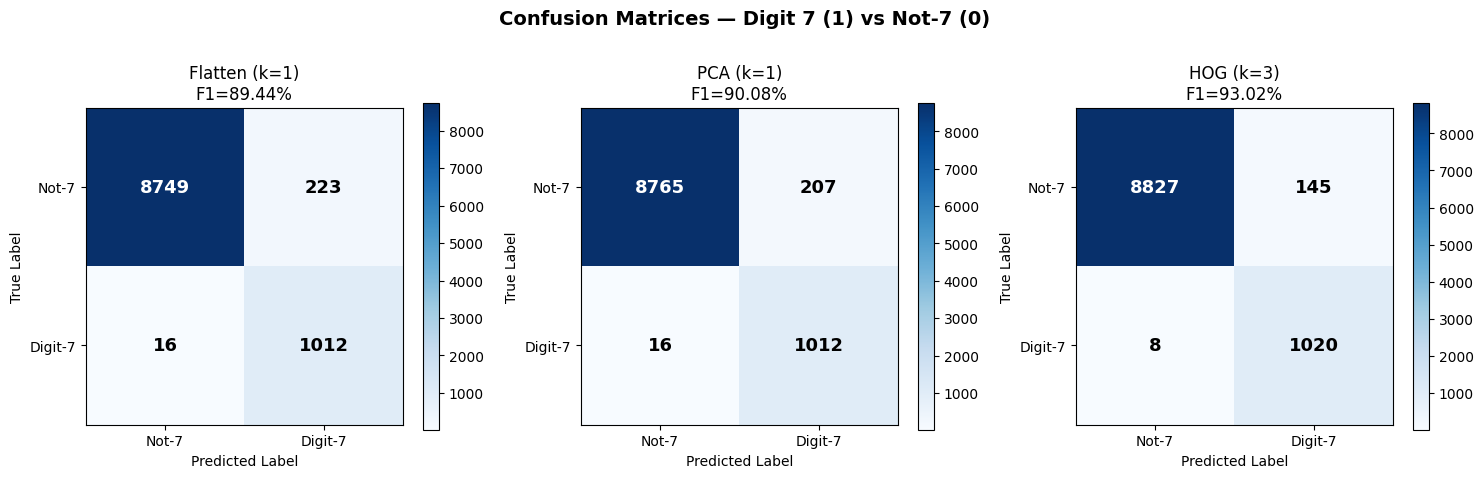

In [33]:
# ── Confusion Matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices — Digit 7 (1) vs Not-7 (0)', fontsize=14, fontweight='bold')

for ax, m in zip(axes, all_metrics):
    cm = m['cm']
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{m['label']} (k={m['k']})\nF1={m['f1']*100:.2f}%", fontsize=12)
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Not-7', 'Digit-7']); ax.set_yticklabels(['Not-7', 'Digit-7'])
    plt.colorbar(im, ax=ax, shrink=0.75)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

In [34]:
best_m = max(all_metrics, key=lambda m: m['f1'])
print(f"\nFull Classification Report — {best_m['label']} (k={best_m['k']})")
print('='*55)
print(classification_report(y_test, best_m['y_pred'],
                            target_names=['Not-7', 'Digit-7']))


Full Classification Report — HOG (k=3)
              precision    recall  f1-score   support

       Not-7       1.00      0.98      0.99      8972
     Digit-7       0.88      0.99      0.93      1028

    accuracy                           0.98     10000
   macro avg       0.94      0.99      0.96     10000
weighted avg       0.99      0.98      0.99     10000

